--- STEP 1: DATASET OVERVIEW ---
Shape: (145460, 23)

--- STEP 2: BASIC EXPLORATION ---

df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    1303

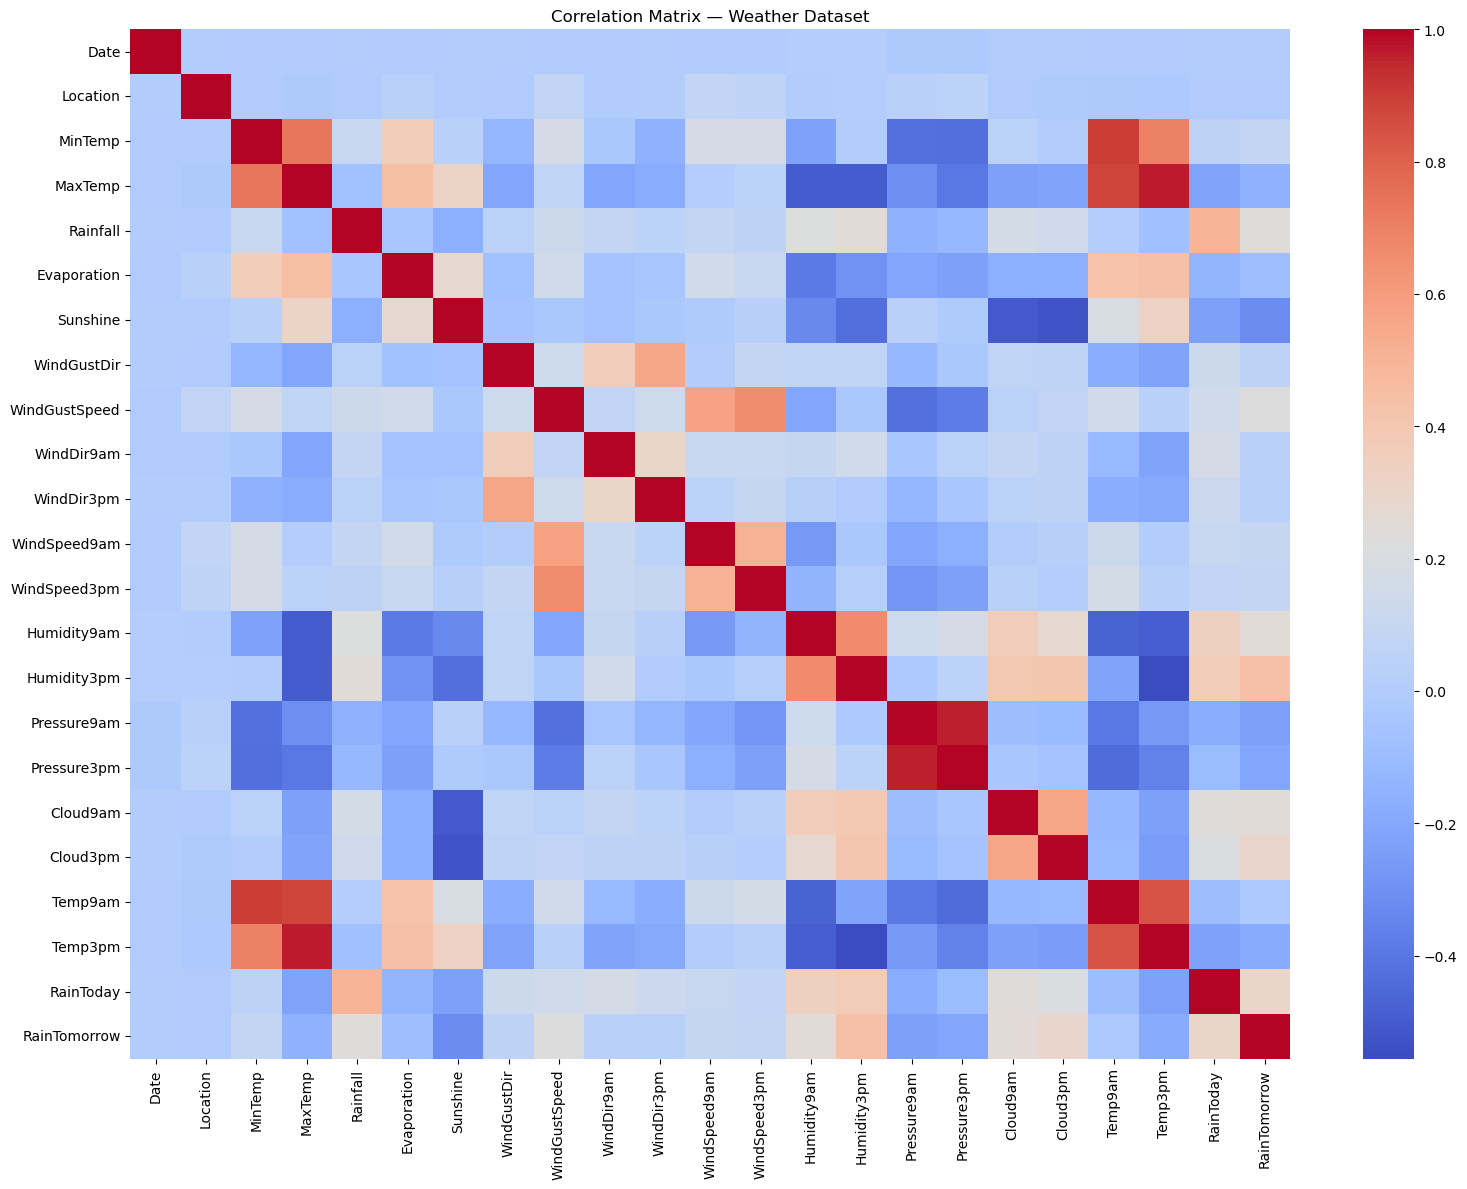


--- STEP 8: DROPPING UNNECESSARY COLUMNS ---
Shape after dropping Date column: (142193, 22)

--- STEP 9: OUTLIER REMOVAL ---


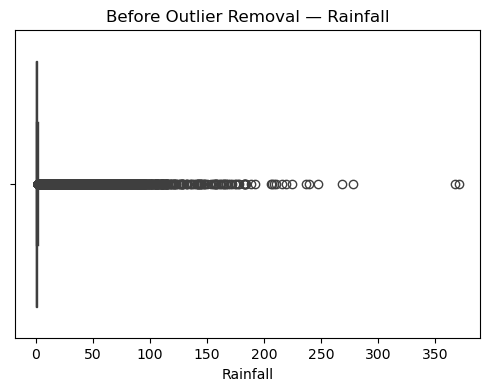

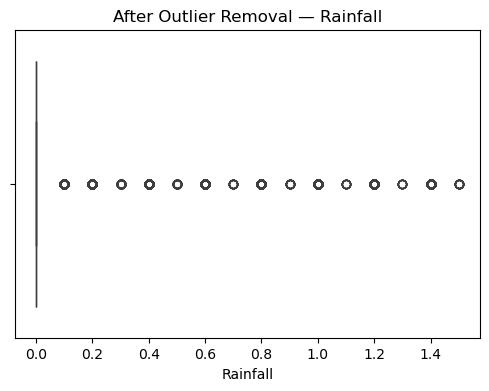

Shape after outlier removal: (113648, 22)

--- STEP 10: NORMALIZATION ---
df.describe() after normalization:
            Location        MinTemp        MaxTemp       Rainfall  \
count  113648.000000  113648.000000  113648.000000  113648.000000   
mean        0.495109       0.483382       0.537952       0.070331   
std         0.297537       0.152607       0.135326       0.183360   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.229167       0.372642       0.438697       0.000000   
50%         0.500000       0.481132       0.528736       0.000000   
75%         0.750000       0.594340       0.634100       0.000000   
max         1.000000       1.000000       1.000000       1.000000   

         Evaporation       Sunshine    WindGustDir  WindGustSpeed  \
count  113648.000000  113648.000000  113648.000000  113648.000000   
mean        0.062572       0.576550       0.518220       0.255398   
std         0.037615       0.179481       0.314337       0.097

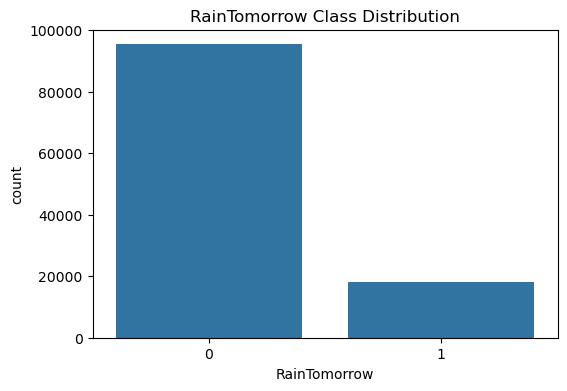


--- STEP 12: FEATURE & TARGET SPLIT ---
X shape: (113648, 21)
y shape: (113648,)

y value counts:
RainTomorrow
0    95420
1    18228
Name: count, dtype: int64

--- STEP 13: SMOTE-TOMEK ---
Before SMOTE-Tomek: {0: 95420, 1: 18228}
After SMOTE-Tomek: {0: 95251, 1: 95251}
X_resampled shape: (190502, 21)


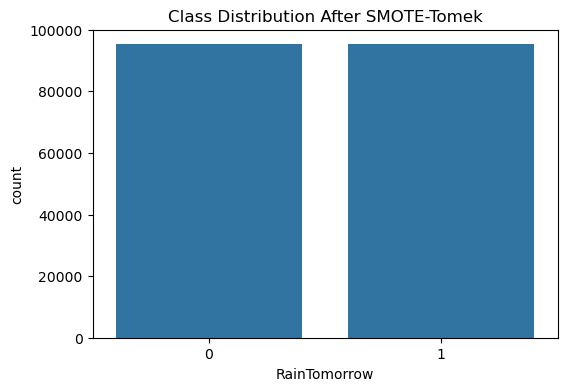


✅ PHASE 1 COMPLETE — Dataset is ML-Ready!


In [1]:
# ============================================
# PHASE 1: EDA — Weather Prediction Project
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


# STEP 1: LOAD DATASET
df = pd.read_csv('weatherAUS.csv')

print("--- STEP 1: DATASET OVERVIEW ---")
print(f"Shape: {df.shape}")


# STEP 2: BASIC EXPLORATION
print("\n--- STEP 2: BASIC EXPLORATION ---")
print("\ndf.info():")
df.info()

print("\ndf.describe():")
print(df.describe())

print("\ndf.columns:")
print(df.columns)

print("\ndf.dtypes:")
print(df.dtypes)

print("\ndf.head():")
print(df.head())

print("\ndf.tail():")
print(df.tail())

print("\ndf.nunique():")
print(df.nunique())


# STEP 3: CHECK DUPLICATES
print("\n--- STEP 3: DUPLICATES ---")
print(f"Total duplicates: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


# STEP 4: CHECK NULL VALUES
print("\n--- STEP 4: NULL VALUES ---")
print(df.isnull().sum())

# Drop rows where target column is null
df.dropna(subset=['RainTomorrow'], inplace=True)
print(f"\nShape after dropping null targets: {df.shape}")


# STEP 5: FILL NULL VALUES
print("\n--- STEP 5: FILLING NULL VALUES ---")

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("Null values after filling:")
print(df.isnull().sum())


# STEP 6: LABEL ENCODING
print("\n--- STEP 6: LABEL ENCODING ---")

categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns: {list(categorical_cols)}")

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

print("\ndf.head() after encoding:")
print(df.head())


# STEP 7: CORRELATION MATRIX
print("\n--- STEP 7: CORRELATION MATRIX ---")

plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix — Weather Dataset')
plt.tight_layout()
plt.show()


# STEP 8: DROP UNNECESSARY COLUMNS
print("\n--- STEP 8: DROPPING UNNECESSARY COLUMNS ---")

# Drop Date column — not useful for ML
df.drop(columns=['Date'], inplace=True)
print(f"Shape after dropping Date column: {df.shape}")


# STEP 9: OUTLIER DETECTION & REMOVAL
# (Moved up — must happen BEFORE scaling so extreme values don't distort
#  the MinMax range and compress normal data toward 0)
print("\n--- STEP 9: OUTLIER REMOVAL ---")

# Check outlier on Rainfall column
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Rainfall'])
plt.title('Before Outlier Removal — Rainfall')
plt.show()

# IQR Method
Q1 = df['Rainfall'].quantile(0.25)
Q3 = df['Rainfall'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Rainfall'] >= lower_bound) & (df['Rainfall'] <= upper_bound)]

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Rainfall'])
plt.title('After Outlier Removal — Rainfall')
plt.show()

print(f"Shape after outlier removal: {df.shape}")


# STEP 10: NORMALIZATION
# (Moved down — now runs AFTER outliers are removed, so MinMax bounds
#  reflect the true, cleaned range of each feature)
print("\n--- STEP 10: NORMALIZATION ---")

# Never normalize target column
target = 'RainTomorrow'
columns_to_scale = [col for col in df.select_dtypes(include=np.number).columns if col != target]

scaler = MinMaxScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("df.describe() after normalization:")
print(df.describe())


# STEP 11: CLASS IMBALANCE CHECK
print("\n--- STEP 11: CLASS IMBALANCE ---")
print(df['RainTomorrow'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='RainTomorrow', data=df)
plt.title('RainTomorrow Class Distribution')
plt.show()


# STEP 12: FEATURE & TARGET SPLIT
print("\n--- STEP 12: FEATURE & TARGET SPLIT ---")
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")


# STEP 13: HANDLE CLASS IMBALANCE — SMOTE-Tomek
from imblearn.combine import SMOTETomek

print("\n--- STEP 13: SMOTE-TOMEK ---")
print(f"Before SMOTE-Tomek: {y.value_counts().to_dict()}")

smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

print(f"After SMOTE-Tomek: {pd.Series(y_resampled).value_counts().to_dict()}")
print(f"X_resampled shape: {X_resampled.shape}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled)
plt.title('Class Distribution After SMOTE-Tomek')
plt.xlabel('RainTomorrow')
plt.show()

print("\n✅ PHASE 1 COMPLETE — Dataset is ML-Ready!")